In [104]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [105]:
df_DA_US = df[
    (df['job_title'] == 'Data Analyst') & 
    (df['job_country'] == 'United States')
].copy()

df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
DA_job_count= len(df_DA_US)
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})
df_DA_skills['skill_percent'] = (df_DA_skills['skill_count']/DA_job_count)*100

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent']>6.5]
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,714,87500.0,63.864043
excel,472,77500.0,42.218247
python,408,90000.0,36.493739
tableau,398,90000.0,35.599284
power bi,279,87500.0,24.955277
r,244,90000.0,21.824687
sas,200,84078.5,17.889088
powerpoint,102,77500.0,9.123435
word,89,75000.0,7.960644


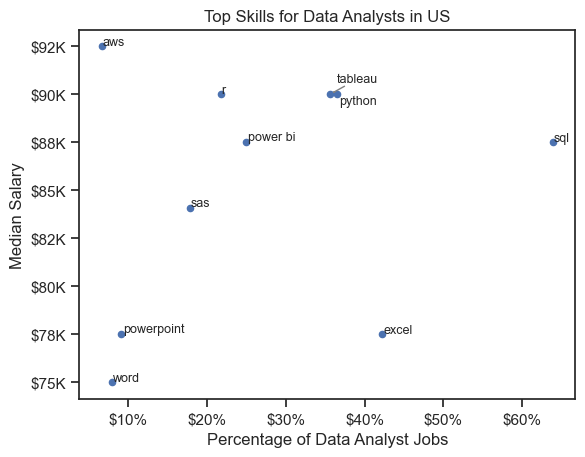

In [106]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter
df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
texts = [plt.text(row['skill_percent'], row['median_salary'], row.name, fontsize=9) for _, row in df_DA_skills_high_demand.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
plt.title("Top Skills for Data Analysts in US")
plt.xlabel("Percentage of Data Analyst Jobs")
plt.ylabel("Median Salary")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'${y/1000:.0f}K')
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.0f}%')
)

plt.show()

In [107]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary

    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing key
            technology_dict[key] += value
        else:  # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))


df_tech = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_tech = df_tech.explode('skills')
df_tech

,technology,skills
0,analyst_tools,tableau
0,analyst_tools,powerpoint
0,analyst_tools,sas
0,analyst_tools,visio
0,analyst_tools,cognos
...,...,...
9,sync,mattermost
9,sync,google chat
9,sync,ringcentral
9,sync,unify


In [108]:
df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,714,87500.0,63.864043
excel,472,77500.0,42.218247
python,408,90000.0,36.493739
tableau,398,90000.0,35.599284
power bi,279,87500.0,24.955277
r,244,90000.0,21.824687
sas,200,84078.5,17.889088
powerpoint,102,77500.0,9.123435
word,89,75000.0,7.960644


In [109]:
df_plot = df_DA_skills_high_demand.merge(df_tech, left_on='job_skills', right_on='skills')

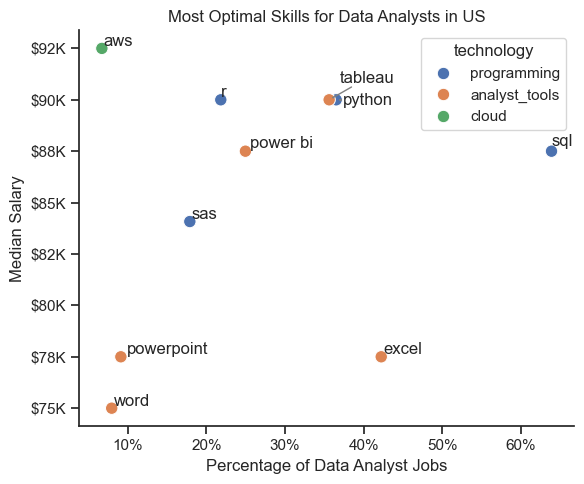

In [111]:
sns.set_theme(style='ticks')

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    s=80
)

texts = [
    plt.text(row['skill_percent'], row['median_salary'], row.name, fontsize=12)
    for _, row in df_DA_skills_high_demand.iterrows()
]

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=1)
)

plt.title("Most Optimal Skills for Data Analysts in US")
plt.xlabel("Percentage of Data Analyst Jobs")
plt.ylabel("Median Salary")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'${y/1000:.0f}K')
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:.0f}%')
)

sns.despine()
plt.tight_layout()
plt.show()